# LSM Pricing and ITM Mask Reuse
Simple notebook to demonstrate the American pricer (with diagnostics/mask) and how mc_fd reuses the mask for bumps.

In [1]:
import pathlib, sys
repo_root = pathlib.Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
import numpy as np
from engines.monte_carlo import MonteCarloPricing
from greeks.mc_fd import MonteCarloFiniteDifference, BumpConfig

In [2]:
pricer = MonteCarloPricing(S_0=100, X=100, sigma=0.2, T=1.0, r=0.05, num_paths=200, steps=40, seed=42)
cashflows, mask = pricer.american_cashflows(
    pricer.simulate_paths(risk_neutral=True, antithetic=False),
    return_mask=True
)
price = cashflows.mean(); price

np.float64(10.191362338497134)

In [3]:
mc_fd = MonteCarloFiniteDifference(pricer, call=False, style="american", bumps=BumpConfig(S_0=1.0), include_all_paths=False)
delta = mc_fd.delta(); delta

-0.4413750091724009

In [4]:
from models.black_scholes import OptionPrice
from greeks.bs_fd import BlackScholesFiniteDifference
euro_pricer = MonteCarloPricing(S_0=100, X=100, sigma=0.2, T=1.0, r=0.05, num_paths=100000, steps=64, seed=123)
euro_fd_mc = MonteCarloFiniteDifference(euro_pricer, call=True, style="european", bumps=BumpConfig(S_0=0.5))
delta_mc = euro_fd_mc.delta()
bs_fd = BlackScholesFiniteDifference(S_0=100, X=100, r=0.05, sigma=0.2, T=1.0, call=True, h_S=0.5)
delta_bs = bs_fd.delta()
delta_mc, delta_bs

(0.6383730902668194, 0.6368091553002699)

# LSM vs Binomial (American, with European MC comparison)
Compare American LSM against American binomial, a Monte Carlo European pricer, and the European Black-Scholes benchmark using a single plain-Monte-Carlo run per volatility.
The reported LSM and European-MC `StdErr` values are single-run Monte Carlo standard errors from that seeded simulation.
Binomial and Black-Scholes are deterministic benchmark rows, so they are evaluated once per volatility and left with blank standard errors.


In [13]:
from models.binomial_method import BinomialPricing
from models.black_scholes import OptionPrice
import numpy as np
import pandas as pd

S0, K, r, T = 100.0, 100.0, 0.05, 1.0
sigmas = [0.15, 0.2, 0.25, 0.3]
steps_tree = 252
steps_mc = steps_tree
paths = 150_000
seed = 42

rows = []
binom_call_prices = {}
binom_put_prices = {}
bs_call_prices = {}
bs_put_prices = {}

for sigma in sigmas:
    pricer = MonteCarloPricing(
        S_0=S0, X=K, sigma=sigma, T=T, r=r,
        num_paths=paths, steps=steps_mc, seed=seed
    )

    # Standard Monte-Carlo LSM with ITM-only regression mask
    lsm_call, lsm_call_se = pricer.american(
        call=True,
        basis_fn="laguerre",
        antithetic=False,
        include_all_paths=False,
        mask_tolerance=0.0,
    )
    lsm_put, lsm_put_se = pricer.american(
        call=False,
        basis_fn="laguerre",
        antithetic=False,
        include_all_paths=False,
        mask_tolerance=0.0,
    )
    euro_call, euro_call_se = pricer.european(call=True, antithetic=False)

    rows.extend([
        {
            "Sigma": sigma,
            "Option": "American Call",
            "Model": "LSM",
            "Price": lsm_call,
            "StdErr": lsm_call_se,
        },
        {
            "Sigma": sigma,
            "Option": "American Put",
            "Model": "LSM",
            "Price": lsm_put,
            "StdErr": lsm_put_se,
        },
        {
            "Sigma": sigma,
            "Option": "American Call",
            "Model": "European MC",
            "Price": euro_call,
            "StdErr": euro_call_se,
        },
    ])

    binom = BinomialPricing(S_0=S0, K=K, r=r, sigma=sigma, T=T, steps=steps_tree)
    binom_call = binom.american(call=True)
    binom_put = binom.american(call=False)

    bs = OptionPrice(S0, K, r, sigma, T)
    bs_call = bs.call()
    bs_put = bs.put()

    binom_call_prices[sigma] = binom_call
    binom_put_prices[sigma] = binom_put
    bs_call_prices[sigma] = bs_call
    bs_put_prices[sigma] = bs_put

    rows.extend([
        {
            "Sigma": sigma,
            "Option": "American Call",
            "Model": "Binomial",
            "Price": binom_call,
            "StdErr": np.nan,
        },
        {
            "Sigma": sigma,
            "Option": "American Call",
            "Model": "Black-Scholes (Euro)",
            "Price": bs_call,
            "StdErr": np.nan,
        },
        {
            "Sigma": sigma,
            "Option": "American Put",
            "Model": "Binomial",
            "Price": binom_put,
            "StdErr": np.nan,
        },
    ])

df = pd.DataFrame(rows)

option_order = pd.CategoricalDtype(["American Call", "American Put"], ordered=True)
model_order = pd.CategoricalDtype(["LSM", "European MC", "Binomial", "Black-Scholes (Euro)"], ordered=True)
df["Option"] = df["Option"].astype(option_order)
df["Model"] = df["Model"].astype(model_order)
df = df.sort_values(["Sigma", "Option", "Model"], kind="stable").reset_index(drop=True)

for sigma in sigmas:
    call_mask = (df["Sigma"] == sigma) & (df["Option"] == "American Call")
    put_mask = (df["Sigma"] == sigma) & (df["Option"] == "American Put")

    binom_call_price = binom_call_prices[sigma]
    binom_put_price = binom_put_prices[sigma]
    bs_call_price = bs_call_prices[sigma]
    bs_put_price = bs_put_prices[sigma]

    df.loc[call_mask, "Diff vs Binomial"] = df.loc[call_mask, "Price"] - binom_call_price
    df.loc[put_mask, "Diff vs Binomial"] = df.loc[put_mask, "Price"] - binom_put_price
    df.loc[call_mask, "Diff vs BS(E)"] = df.loc[call_mask, "Price"] - bs_call_price
    df.loc[put_mask, "Diff vs BS(E)"] = df.loc[put_mask, "Price"] - bs_put_price

pd.options.display.float_format = "{:.6f}".format

df


,Sigma,Option,Model,Price,StdErr,Diff vs Binomial,Diff vs BS(E)
0,0.150000,American Call,LSM,8.629424,0.028741,0.043842,0.037766
1,0.150000,American Call,European MC,8.630763,0.028815,0.045180,0.039104
2,0.150000,American Call,Binomial,8.585582,NaN,0.000000,-0.006076
3,0.150000,American Call,Black-Scholes (Euro),8.591658,NaN,0.006076,0.000000
4,0.150000,American Put,LSM,4.228270,0.013059,-0.002132,0.513669
5,0.150000,American Put,Binomial,4.230402,NaN,0.000000,0.515801
6,0.200000,American Call,LSM,10.502446,0.037941,0.059794,0.051862
7,0.200000,American Call,European MC,10.503244,0.038077,0.060592,0.052660
8,0.200000,American Call,Binomial,10.442652,NaN,0.000000,-0.007931
9,0.200000,American Call,Black-Scholes (Euro),10.450584,NaN,0.007931,0.000000


# Plots: LSM vs Binomial across sigmas and convergence


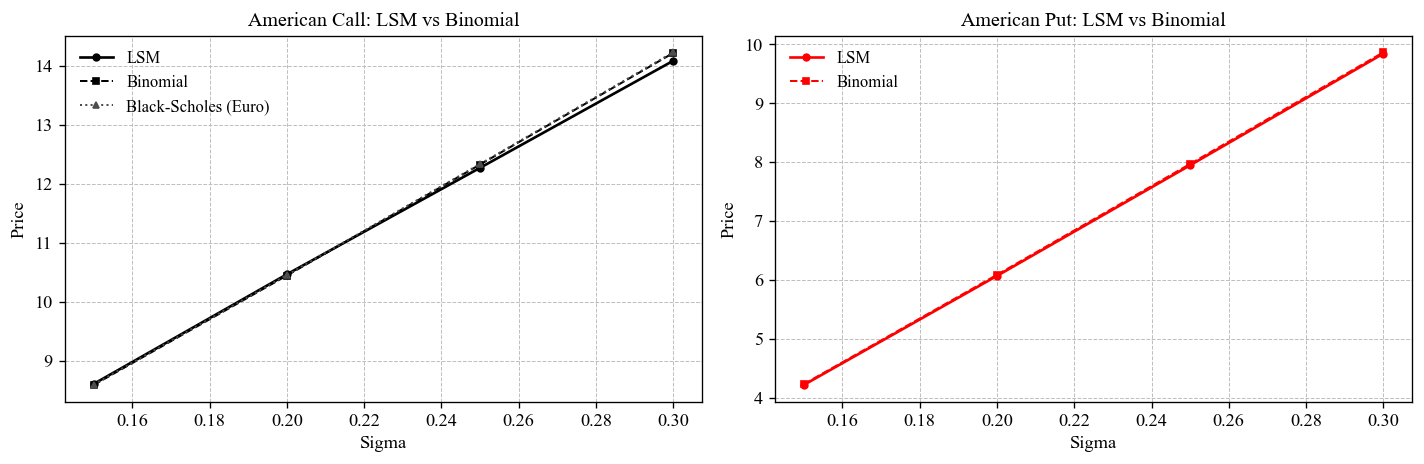

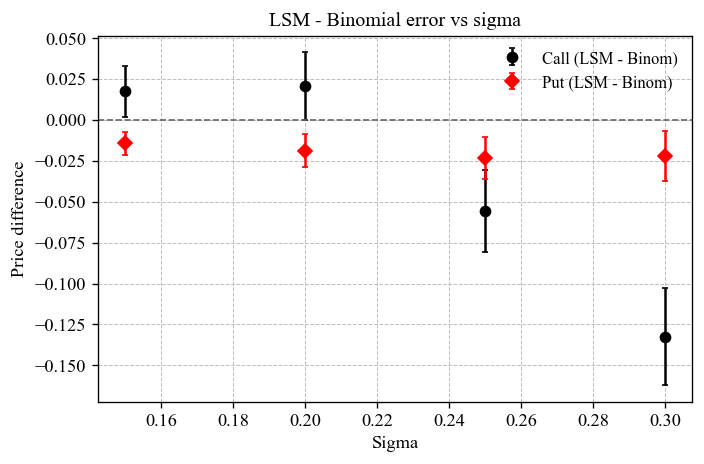

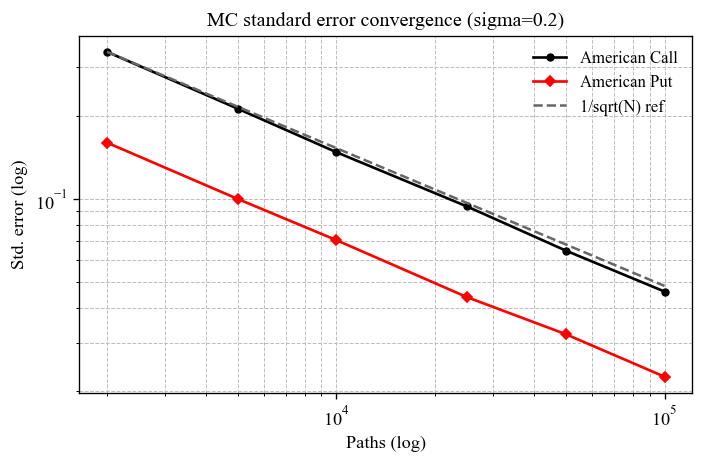

In [12]:
import numpy as np
import matplotlib.pyplot as plt
# Academic-style plotting defaults
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Palatino", "Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "black",
    "grid.color": "0.75",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "figure.dpi": 120,
    "legend.frameon": False,
})

if "df" not in globals():
    raise RuntimeError("Run the LSM vs Binomial table cell first to build df.")

sigmas_sorted = sorted(df["Sigma"].unique())


def _series(option: str, model: str, field: str = "Price") -> np.ndarray:
    subset = df[(df["Option"] == option) & (df["Model"] == model)].set_index("Sigma")
    return subset.loc[sigmas_sorted, field].to_numpy()


lsm_call = _series("American Call", "LSM")
binom_call = _series("American Call", "Binomial")
bs_call = _series("American Call", "Black-Scholes (Euro)")
lsm_put = _series("American Put", "LSM")
binom_put = _series("American Put", "Binomial")

# LSM vs Binomial prices across sigmas
fig, axes = plt.subplots(ncols=2, figsize=(12, 4), sharex=True)
axes[0].plot(
    sigmas_sorted,
    lsm_call,
    marker="o",
    markersize=4,
    linewidth=1.6,
    color="black",
    label="LSM",
)
axes[0].plot(
    sigmas_sorted,
    binom_call,
    marker="s",
    markersize=4,
    linewidth=1.2,
    linestyle="--",
    color="black",
    label="Binomial",
)
axes[0].plot(
    sigmas_sorted,
    bs_call,
    marker="^",
    markersize=4,
    linewidth=1.2,
    linestyle=":",
    color="0.3",
    label="Black-Scholes (Euro)",
)
axes[0].set_title("American Call: LSM vs Binomial")
axes[0].set_xlabel("Sigma")
axes[0].set_ylabel("Price")
axes[0].grid(True, which="both")
axes[0].legend()

axes[1].plot(
    sigmas_sorted,
    lsm_put,
    marker="o",
    markersize=4,
    linewidth=1.6,
    color="red",
    label="LSM",
)
axes[1].plot(
    sigmas_sorted,
    binom_put,
    marker="s",
    markersize=4,
    linewidth=1.2,
    linestyle="--",
    color="red",
    label="Binomial",
)
axes[1].set_title("American Put: LSM vs Binomial")
axes[1].set_xlabel("Sigma")
axes[1].set_ylabel("Price")
axes[1].grid(True, which="both")
axes[1].legend()

plt.tight_layout()
plt.show()

# Scatter of LSM - Binomial error vs sigma (with MC SE)
err_call = lsm_call - binom_call
err_put = lsm_put - binom_put
se_call = _series("American Call", "LSM", field="StdErr")
se_put = _series("American Put", "LSM", field="StdErr")

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(
    sigmas_sorted,
    err_call,
    yerr=se_call,
    fmt="o",
    color="black",
    ecolor="black",
    capsize=2,
    label="Call (LSM - Binom)",
)
ax.errorbar(
    sigmas_sorted,
    err_put,
    yerr=se_put,
    fmt="D",
    color="red",
    ecolor="red",
    capsize=2,
    label="Put (LSM - Binom)",
)
ax.axhline(0.0, color="0.4", linewidth=1.0, linestyle="--")
ax.set_title("LSM - Binomial error vs sigma")
ax.set_xlabel("Sigma")
ax.set_ylabel("Price difference")
ax.grid(True, which="both")
ax.legend()

plt.tight_layout()
plt.show()

# Standard error convergence vs number of paths (single sigma)
sigma_conv = 0.2 if 0.2 in sigmas_sorted else sigmas_sorted[len(sigmas_sorted) // 2]
paths_list = [2_000, 5_000, 10_000, 25_000, 50_000, 100_000]

records = []
for n_paths in paths_list:
    pricer = MonteCarloPricing(
        S_0=S0, X=K, sigma=sigma_conv, T=T, r=r,
        num_paths=n_paths, steps=steps_mc, seed=seed
    )
    _, se_call_n = pricer.american(
        call=True,
        basis_fn="laguerre",
        antithetic=False,
        include_all_paths=False,
        mask_tolerance=0.0,
    )
    _, se_put_n = pricer.american(
        call=False,
        basis_fn="laguerre",
        antithetic=False,
        include_all_paths=False,
        mask_tolerance=0.0,
    )
    records.append({
        "Option": "American Call",
        "Paths": n_paths,
        "StdErr": se_call_n,
    })
    records.append({
        "Option": "American Put",
        "Paths": n_paths,
        "StdErr": se_put_n,
    })

conv = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(6, 4))

call_subset = conv[conv["Option"] == "American Call"]
put_subset = conv[conv["Option"] == "American Put"]

ax.plot(
    call_subset["Paths"],
    call_subset["StdErr"],
    marker="o",
    markersize=4,
    linewidth=1.6,
    color="black",
    label="American Call",
)
ax.plot(
    put_subset["Paths"],
    put_subset["StdErr"],
    marker="D",
    markersize=4,
    linewidth=1.6,
    color="red",
    label="American Put",
)

# Reference 1/sqrt(N) line based on the first call point
ref = call_subset["StdErr"].iloc[0] * (call_subset["Paths"].iloc[0] / call_subset["Paths"]) ** 0.5
ax.plot(call_subset["Paths"], ref, linestyle="--", color="0.4", label="1/sqrt(N) ref")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title(f"MC standard error convergence (sigma={sigma_conv})")
ax.set_xlabel("Paths (log)")
ax.set_ylabel("Std. error (log)")
ax.grid(True, which="both")
ax.legend()

plt.tight_layout()
plt.show()


# Summary tables


In [14]:
import numpy as np
import pandas as pd

if "df" not in globals():
    raise RuntimeError("Run the LSM vs Binomial table cell first to build df.")

# Scenario metadata (edit if needed for the thesis text)
scenario = {
    "S0": S0,
    "K": K,
    "r": r,
    "T": T,
    "steps_tree": steps_tree,
    "steps_mc": steps_mc,
    "paths": paths,
    "seed": seed,
}
print("Scenario:", scenario)

summary = df[["Sigma", "Option", "Model", "Price", "StdErr", "Diff vs BS(E)", "Diff vs Binomial"]].copy()
summary = summary.rename(columns={"StdErr": "StdERR", "Diff vs BS(E)": "Diff vs BS"})

calls = summary.loc[summary["Option"] == "American Call", ["Sigma", "Model", "Price", "StdERR", "Diff vs BS", "Diff vs Binomial"]].reset_index(drop=True)
puts = summary.loc[summary["Option"] == "American Put", ["Sigma", "Model", "Price", "StdERR", "Diff vs BS", "Diff vs Binomial"]].reset_index(drop=True)

pd.options.display.float_format = "{:.6f}".format

print("American Calls")
display(calls)
print("\nAmerican Puts")
display(puts)

# LaTeX outputs for thesis write-up
latex_calls = calls.to_latex(index=False, float_format="%.6f",
                            caption="American call: plain Monte Carlo LSM and Monte Carlo European pricing from a single seeded simulation, versus American binomial and European Black-Scholes (no dividends). The reported StdERR values for the stochastic methods are single-run Monte Carlo standard errors; binomial and Black-Scholes are deterministic benchmark rows.",
                            label="tab:lsm_binom_call")
latex_puts = puts.to_latex(index=False, float_format="%.6f",
                           caption="American put: plain Monte Carlo LSM from a single seeded simulation versus the American binomial benchmark. The reported LSM StdERR is the single-run Monte Carlo standard error; Diff vs BS is retained only as a reference column.",
                           label="tab:lsm_binom_put")

latex_calls, latex_puts


Scenario: {'S0': 100.0, 'K': 100.0, 'r': 0.05, 'T': 1.0, 'steps_tree': 252, 'steps_mc': 252, 'paths': 150000, 'seed': 42}
American Calls


,Sigma,Model,Price,StdERR,Diff vs BS,Diff vs Binomial
0,0.150000,LSM,8.629424,0.028741,0.037766,0.043842
1,0.150000,European MC,8.630763,0.028815,0.039104,0.045180
2,0.150000,Binomial,8.585582,NaN,-0.006076,0.000000
3,0.150000,Black-Scholes (Euro),8.591658,NaN,0.000000,0.006076
4,0.200000,LSM,10.502446,0.037941,0.051862,0.059794
5,0.200000,European MC,10.503244,0.038077,0.052660,0.060592
6,0.200000,Binomial,10.442652,NaN,-0.007931,0.000000
7,0.200000,Black-Scholes (Euro),10.450584,NaN,0.000000,0.007931
8,0.250000,LSM,12.308670,0.045780,-0.027328,-0.017524
9,0.250000,European MC,12.401524,0.047872,0.065525,0.075329



American Puts


,Sigma,Model,Price,StdERR,Diff vs BS,Diff vs Binomial
0,0.150000,LSM,4.228270,0.013059,0.513669,-0.002132
1,0.150000,Binomial,4.230402,NaN,0.515801,0.000000
2,0.200000,LSM,6.078742,0.018242,0.505216,-0.008464
3,0.200000,Binomial,6.087205,NaN,0.513679,0.000000
4,0.250000,LSM,7.958345,0.023289,0.499404,-0.011890
5,0.250000,Binomial,7.970235,NaN,0.511294,0.000000
6,0.300000,LSM,9.855781,0.028155,0.501584,-0.008849
7,0.300000,Binomial,9.864630,NaN,0.510433,0.000000


('\\begin{table}\n\\caption{American call: plain Monte Carlo LSM and Monte Carlo European pricing from a single seeded simulation, versus American binomial and European Black-Scholes (no dividends). The reported StdERR values for the stochastic methods are single-run Monte Carlo standard errors; binomial and Black-Scholes are deterministic benchmark rows.}\n\\label{tab:lsm_binom_call}\n\\begin{tabular}{rlrrrr}\n\\toprule\nSigma & Model & Price & StdERR & Diff vs BS & Diff vs Binomial \\\\\n\\midrule\n0.150000 & LSM & 8.629424 & 0.028741 & 0.037766 & 0.043842 \\\\\n0.150000 & European MC & 8.630763 & 0.028815 & 0.039104 & 0.045180 \\\\\n0.150000 & Binomial & 8.585582 & NaN & -0.006076 & 0.000000 \\\\\n0.150000 & Black-Scholes (Euro) & 8.591658 & NaN & 0.000000 & 0.006076 \\\\\n0.200000 & LSM & 10.502446 & 0.037941 & 0.051862 & 0.059794 \\\\\n0.200000 & European MC & 10.503244 & 0.038077 & 0.052660 & 0.060592 \\\\\n0.200000 & Binomial & 10.442652 & NaN & -0.007931 & 0.000000 \\\\\n0.2000

# Exercise profile (American put)


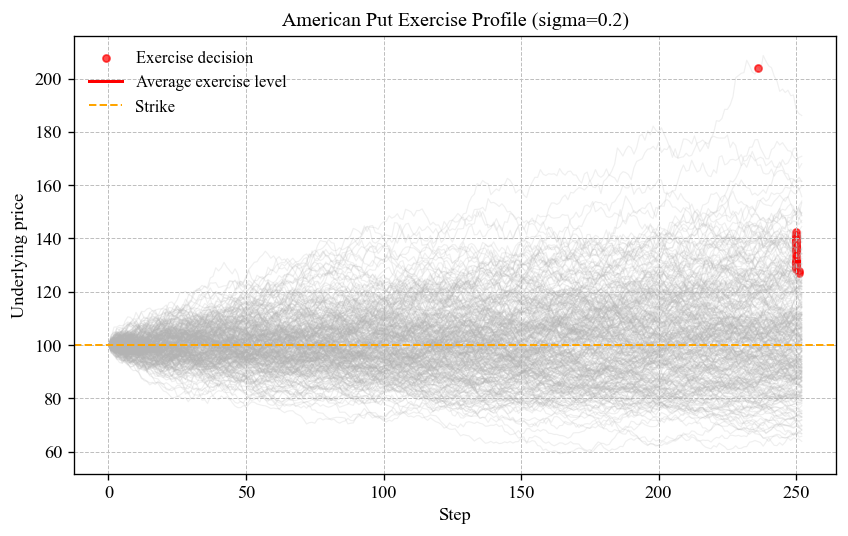

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Match the academic plotting style used above
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Palatino", "Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "black",
    "grid.color": "0.75",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "figure.dpi": 120,
    "legend.frameon": False,
})

sigma_profile = 0.2
profile_paths = min(paths, 200_000)
profile_steps = steps_mc

pricer = MonteCarloPricing(
    S_0=S0,
    X=K,
    sigma=sigma_profile,
    T=T,
    r=r,
    num_paths=profile_paths,
    steps=profile_steps,
    seed=seed,
)

_, _, diagnostics = pricer.american(
    call=True,
    basis_fn="laguerre",
    antithetic=False,
    include_all_paths=False,
    mask_tolerance=0.0,
    return_diagnostics=True,
)

paths_arr = diagnostics["paths"]
exercise_mask = diagnostics["exercise_mask"]

n_steps, n_paths = paths_arr.shape
step_grid = np.arange(n_steps)

max_paths = min(n_paths, 300)
path_indices = np.arange(max_paths)

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for idx in path_indices:
    ax.plot(step_grid, paths_arr[:, idx], color="0.7", alpha=0.2, linewidth=0.7)

mask_subset = exercise_mask[:, path_indices]
if mask_subset.any():
    t_idx, p_idx = np.nonzero(mask_subset)
    ax.scatter(t_idx, paths_arr[t_idx, path_indices[p_idx]],
               c="red", s=18, alpha=0.7, label="Exercise decision")

# Average exercise boundary (smoothed), require a minimum count of exercises
ex_counts = exercise_mask.sum(axis=1)
min_ex_count = max(5, int(0.001 * n_paths))

boundary = np.full(exercise_mask.shape[0], np.nan)
for t in range(exercise_mask.shape[0]):
    if ex_counts[t] < min_ex_count:
        continue
    exercised_states = paths_arr[t, exercise_mask[t]]
    if exercised_states.size:
        boundary[t] = np.mean(exercised_states)

boundary_smooth = np.full_like(boundary, np.nan)
window = 4
for i in range(boundary.size):
    if np.isnan(boundary[i]):
        continue
    lo = max(0, i - window)
    hi = min(boundary.size, i + window + 1)
    vals = boundary[lo:hi]
    vals = vals[~np.isnan(vals)]
    if vals.size:
        boundary_smooth[i] = np.mean(vals)

valid = np.where(~np.isnan(boundary_smooth))[0]
if valid.size:
    start_idx = int(valid[0])
    end_idx = int(valid[-1])
    ax.plot(step_grid[start_idx:end_idx + 1], boundary_smooth[start_idx:end_idx + 1],
            color="red", linewidth=1.8, label="Average exercise level")
ax.axhline(K, color="orange", linestyle="--", linewidth=1.2, label="Strike")

ax.set_title(f"American Put Exercise Profile (sigma={sigma_profile})")
ax.set_xlabel("Step")
ax.set_ylabel("Underlying price")
ax.grid(True, which="both")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()


# Exercise density heatmap (American put)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Use the same diagnostics from the exercise profile section
paths_arr = diagnostics["paths"]
exercise_mask = diagnostics["exercise_mask"]

n_steps = exercise_mask.shape[0]

# Collect exercised points (time step, moneyness)
ex_t, ex_p = np.nonzero(exercise_mask)
if ex_t.size == 0:
    raise RuntimeError("No exercised points found; check parameters or paths.")

moneyness = (paths_arr[ex_t, ex_p] / K).astype(float)

# Focus on the central mass of exercised points for readability
lo, hi = np.percentile(moneyness, [2, 98])
lo = max(0.6, float(lo))
hi = min(1.0, float(hi))
if hi <= lo:
    lo, hi = 0.75, 1.0

x_edges = np.arange(n_steps + 1)
y_edges = np.linspace(lo, hi, 40)

hist, _, _ = np.histogram2d(ex_t, moneyness, bins=[x_edges, y_edges])

# Mask zeros so LogNorm doesn't blow out empty bins
hist = hist.T
hist[hist == 0] = np.nan

fig, ax = plt.subplots(figsize=(7.2, 4.6))
mesh = ax.pcolormesh(x_edges, y_edges, hist, shading="auto",
                     cmap="viridis", norm=LogNorm())
cb = plt.colorbar(mesh, ax=ax, pad=0.02)
cb.set_label("Exercise count (log scale)")

# 95th percentile boundary of exercised moneyness by time (smoothed)
boundary = np.full(n_steps, np.nan)
for t in range(n_steps):
    exercised_states = paths_arr[t, exercise_mask[t]] / K
    if exercised_states.size:
        boundary[t] = np.percentile(exercised_states, 95)

boundary_smooth = boundary.copy()
window = 4
for i in range(boundary.size):
    lo_i = max(0, i - window)
    hi_i = min(boundary.size, i + window + 1)
    vals = boundary[lo_i:hi_i]
    vals = vals[~np.isnan(vals)]
    if vals.size:
        boundary_smooth[i] = np.mean(vals)

ax.plot(np.arange(n_steps), boundary_smooth, color="black", linewidth=1.8,
        label="95th percentile boundary")

ax.set_title(f"American Put Exercise Density (sigma={sigma_profile})")
ax.set_xlabel("Step")
ax.set_ylabel("Moneyness (S/K)")
ax.set_ylim(lo, hi)
ax.grid(False)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()





ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x111896700> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 864x552 with 2 Axes>

In [ ]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


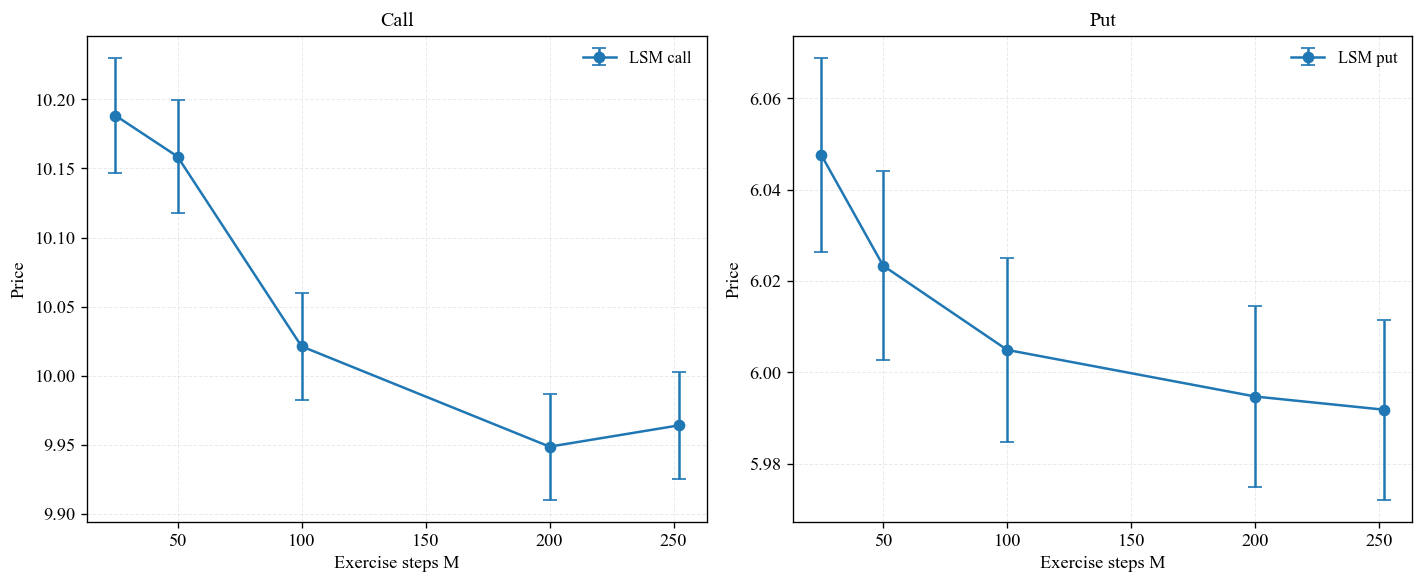

In [ ]:
# Bermudan discretisation error: price vs M (N fixed)
import numpy as np
import matplotlib.pyplot as plt

from engines.monte_carlo import MonteCarloPricing
from models.binomial_method import BinomialPricing

# parameters (keep N large, vary M)
S0 = 100.0
K = 100.0
sigma = 0.2
r = 0.05
T = 1.0
N = 100_000
M_list = [25, 50, 100, 200, 252]
seed = 42
basis = 'laguerre'

def lsm_price_for_M(M, call):
    pricer = MonteCarloPricing(
        S_0=S0, X=K, sigma=sigma, T=T, r=r,
        num_paths=N, steps=M, seed=seed
    )
    price, se = pricer.american(call=call, basis_fn=basis, antithetic=False)
    return float(price), float(se)

call_prices, call_se = [], []
put_prices, put_se = [], []
for M in M_list:
    p, se = lsm_price_for_M(M, call=True)
    call_prices.append(p)
    call_se.append(se)
    p, se = lsm_price_for_M(M, call=False)
    put_prices.append(p)
    put_se.append(se)

# optional binomial benchmark
#binom_steps = 1000
#binom = BinomialPricing(S_0=S0, K=K, r=r, sigma=sigma, T=T, steps=binom_steps)
#binom_call = binom.american(call=True)
#binom_put = binom.american(call=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].errorbar(M_list, call_prices, yerr=call_se, fmt='o-', capsize=4, label='LSM call')
axes[1].errorbar(M_list, put_prices, yerr=put_se, fmt='o-', capsize=4, label='LSM put')
#axes[0].axhline(binom_call, color='0.4', linestyle='--', label='Binomial')
#axes[1].axhline(binom_put, color='0.4', linestyle='--', label='Binomial')

axes[0].set_title('Call')
axes[1].set_title('Put')
for ax in axes:
    ax.set_xlabel('Exercise steps M')
    ax.set_ylabel('Price')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()
